# ============= IMPORTAR LIBRERÍAS ==============

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

In [2]:
def audit_missing(df: pd.DataFrame) -> pd.DataFrame:
    return (
        pd.DataFrame({
            "dtype": df.dtypes.astype(str),
            "n_missing": df.isna().sum(),
            "pct_missing": (df.isna().mean() * 100).round(2),
            "n_unique": df.nunique(dropna=True)
        })
        .sort_values("pct_missing", ascending=False)
    )

def to_datetime_safe(s: pd.Series, fmt: str | None = None) -> pd.Series:
    return pd.to_datetime(s, errors="coerce", format=fmt)

def pct_to_num(s: pd.Series) -> pd.Series:
    # Convierte "85%" -> 85, y valores raros -> NaN
    return pd.to_numeric(s.astype(str).str.replace("%", "", regex=False), errors="coerce")

def fmt_min_to_hm(minutes: float) -> str:
    if minutes is None or (isinstance(minutes, float) and np.isnan(minutes)):
        return "NA"
    m = int(round(float(minutes)))
    h = m // 60
    mm = m % 60
    return f"{h}h {mm:02d}m"

def spearman_pair(df: pd.DataFrame, x: str, y: str) -> dict:
    tmp = df[[x, y]].dropna()
    r, p = spearmanr(tmp[x], tmp[y])
    return {"n": int(tmp.shape[0]), "spearman_r": float(r), "p_value": float(p)}

# ============= CARGAR DATASET ==============

In [3]:
df_raw = pd.read_csv('C://Users//mitev//Desktop//Prácticas/SLEEP_CYCLE_PROYECT/dataset/My complete sleep data.csv',sep=";")

# ======== DATA PREPARATION =========

In [4]:
audit = audit_missing(df_raw)

# Drop columnas con >= 90% nulos
cols_drop_90 = audit.index[audit["pct_missing"] >= 90].tolist()
df_1 = df_raw.drop(columns=cols_drop_90).copy()

print("shape original:", df_raw.shape)
print("shape tras drop >=90% nulos:", df_1.shape)
print("columnas eliminadas:", cols_drop_90)

audit.head(12)

shape original: (277, 26)
shape tras drop >=90% nulos: (277, 22)
columnas eliminadas: ['Alertness accuracy', 'Alertness reaction time (seconds)', 'Alertness score', 'Notes']


,dtype,n_missing,pct_missing,n_unique
Alertness accuracy,float64,277,100.00,0
Alertness reaction time (seconds),float64,277,100.00,0
Alertness score,float64,277,100.00,0
Notes,object,265,95.67,11
Air Pressure (Pa),float64,249,89.89,25
City,object,233,84.12,1
Weather temperature (°C),float64,143,51.62,13
Weather type,object,143,51.62,5
Wake up window start,object,47,16.97,229
Wake up window stop,object,47,16.97,229


In [5]:
df_2 = df_1.copy()

# Fechas principales
if "Went to bed" in df_2.columns:
    df_2["Went to bed"] = to_datetime_safe(df_2["Went to bed"])
if "Woke up" in df_2.columns:
    df_2["Woke up"] = to_datetime_safe(df_2["Woke up"])

# Wake up window con año en 2 dígitos (si existe)
for c in ["Wake up window start", "Wake up window stop"]:
    if c in df_2.columns:
        df_2[c] = to_datetime_safe(df_2[c], fmt="%y-%m-%d %H:%M:%S")

# Porcentajes
if "Sleep Quality" in df_2.columns:
    df_2["Sleep Quality"] = pct_to_num(df_2["Sleep Quality"])

if "Regularity" in df_2.columns:
    # reemplazar el guion largo “—”
    df_2["Regularity"] = df_2["Regularity"].replace("—", np.nan)
    df_2["Regularity"] = pct_to_num(df_2["Regularity"])

# Corregir placeholder de Woke up: 1969-12-31 23:59:59 -> NaT
placeholder_woke = pd.Timestamp("1969-12-31 23:59:59")
df_2["flag_woke_placeholder_fixed"] = False
if "Woke up" in df_2.columns:
    df_2["flag_woke_placeholder_fixed"] = df_2["Woke up"].eq(placeholder_woke)
    df_2.loc[df_2["flag_woke_placeholder_fixed"], "Woke up"] = pd.NaT

# Duración calculada por timestamps
df_2["in_bed_seconds_calc"] = np.nan
if "Went to bed" in df_2.columns and "Woke up" in df_2.columns:
    df_2["in_bed_seconds_calc"] = (df_2["Woke up"] - df_2["Went to bed"]).dt.total_seconds()

# Comparación con la métrica de la app si existe
df_2["flag_inbed_mismatch_10min"] = False
if "Time in bed (seconds)" in df_2.columns:
    df_2["in_bed_diff"] = df_2["in_bed_seconds_calc"] - df_2["Time in bed (seconds)"]
    df_2["flag_inbed_mismatch_10min"] = df_2["in_bed_diff"].abs() > 600
else:
    df_2["in_bed_diff"] = np.nan

# Decisión: time_in_bed_final = Time in bed (seconds) como referencia y calc como fallback
if "Time in bed (seconds)" in df_2.columns:
    df_2["time_in_bed_final"] = df_2["Time in bed (seconds)"].where(
        df_2["Time in bed (seconds)"].notna(),
        df_2["in_bed_seconds_calc"]
    )
else:
    df_2["time_in_bed_final"] = df_2["in_bed_seconds_calc"]

# Flag: sesión sin sueño real (asleep=0 con tiempo en cama >0)
df_2["flag_no_sleep_session"] = False
if "Time asleep (seconds)" in df_2.columns:
    df_2["flag_no_sleep_session"] = (
        df_2["Time asleep (seconds)"].fillna(-1).eq(0)
        & df_2["time_in_bed_final"].notna()
        & (df_2["time_in_bed_final"] > 0)
    )

# Métricas en minutos + eficiencia
df_2["time_in_bed_min"] = df_2["time_in_bed_final"] / 60
df_2["time_asleep_min"] = np.nan
df_2["sleep_efficiency_pct"] = np.nan
if "Time asleep (seconds)" in df_2.columns:
    df_2["time_asleep_min"] = df_2["Time asleep (seconds)"] / 60
    df_2["sleep_efficiency_pct"] = (df_2["Time asleep (seconds)"] / df_2["time_in_bed_final"]) * 100

# Componentes: latencia y tiempo despierto en cama
df_2["latency_min"] = np.nan
if "Asleep after (seconds)" in df_2.columns:
    df_2["latency_min"] = df_2["Asleep after (seconds)"] / 60

df_2["awake_in_bed_min"] = np.nan
if "Time asleep (seconds)" in df_2.columns:
    df_2["awake_in_bed_min"] = (df_2["time_in_bed_final"] - df_2["Time asleep (seconds)"]) / 60

# Dataset para EDA principal: sesiones con sueño real (time_asleep > 0)
df_sleep = df_2[df_2["Time asleep (seconds)"].fillna(0) > 0].copy()

# Outliers de duración
df_sleep["flag_outlier_high"] = (df_sleep["time_asleep_min"] > 900) | (df_sleep["time_in_bed_min"] > 1000)
df_sleep["flag_outlier_low"] = (df_sleep["time_asleep_min"] < 180)

# Dataset principal sin outliers altos
df_sleep_main = df_sleep.loc[~df_sleep["flag_outlier_high"]].copy()

print("placeholder corregidos:", int(df_2["flag_woke_placeholder_fixed"].sum()))
print("mismatch >10min:", int(df_2["flag_inbed_mismatch_10min"].sum()))
print("no sleep sessions:", int(df_2["flag_no_sleep_session"].sum()))
print("df_sleep:", df_sleep.shape, "outliers_high:", int(df_sleep["flag_outlier_high"].sum()))
print("df_sleep_main:", df_sleep_main.shape)

placeholder corregidos: 1
mismatch >10min: 1
no sleep sessions: 1
df_sleep: (275, 35) outliers_high: 2
df_sleep_main: (273, 35)


In [6]:
cols_final = [
    "Went to bed", "Woke up",
    "Sleep Quality", "Regularity",
    "time_asleep_min", "time_in_bed_min",
    "sleep_efficiency_pct", "latency_min", "awake_in_bed_min",
    "flag_outlier_high", "flag_outlier_low", "flag_no_sleep_session"
]
cols_final = [c for c in cols_final if c in df_sleep_main.columns]

df_final = df_sleep_main[cols_final].copy()

df_analysis = df_final.copy()
df_analysis.loc[df_analysis["Regularity"].eq(0), "Regularity"] = pd.NA

print("df_final:", df_final.shape)
df_final.head()

df_final: (273, 12)


,Went to bed,Woke up,Sleep Quality,Regularity,time_asleep_min,time_in_bed_min,sleep_efficiency_pct,latency_min,awake_in_bed_min,flag_outlier_high,flag_outlier_low,flag_no_sleep_session
0,2025-01-25 22:51:43,2025-01-26 07:08:14,85,NaN,382.300000,496.500000,76.998993,9.916667,114.200000,False,False,False
1,2025-01-26 23:00:04,2025-01-27 01:38:08,27,53.0,105.366667,158.066667,66.659637,3.150000,52.700000,False,True,False
2,2025-01-27 02:49:25,2025-01-27 08:36:38,25,53.0,278.916667,347.200000,80.333141,6.933333,68.283333,False,False,False
3,2025-01-28 00:48:09,2025-01-28 08:33:46,82,40.0,313.500000,465.600000,67.332474,9.300000,152.100000,False,False,False
4,2025-01-29 23:17:38,2025-01-30 07:30:11,91,53.0,375.966667,492.550000,76.330660,9.850000,116.583333,False,False,False


# ================== EDA ===================

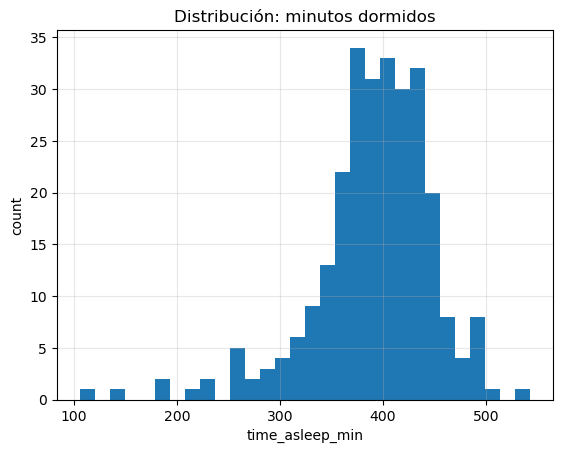

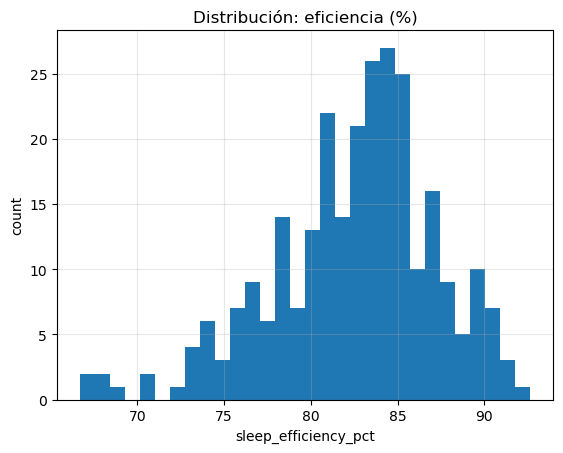

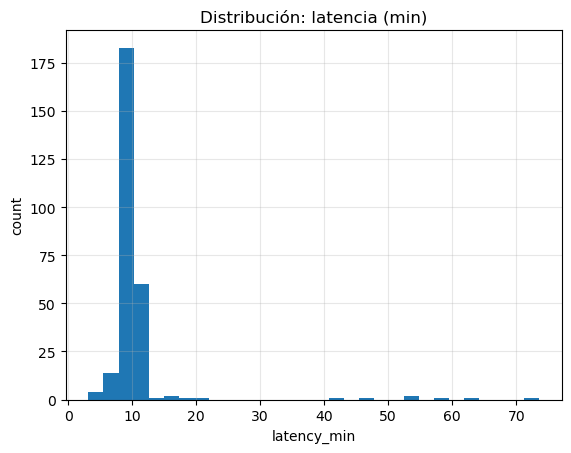

In [7]:
plt.figure()
df_analysis["time_asleep_min"].dropna().hist(bins=30)
plt.title("Distribución: minutos dormidos")
plt.xlabel("time_asleep_min")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
df_analysis["sleep_efficiency_pct"].dropna().hist(bins=30)
plt.title("Distribución: eficiencia (%)")
plt.xlabel("sleep_efficiency_pct")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

if df_analysis["latency_min"].notna().any():
    plt.figure()
    df_analysis["latency_min"].dropna().hist(bins=30)
    plt.title("Distribución: latencia (min)")
    plt.xlabel("latency_min")
    plt.ylabel("count")
    plt.grid(True, alpha=0.3)
    plt.show()

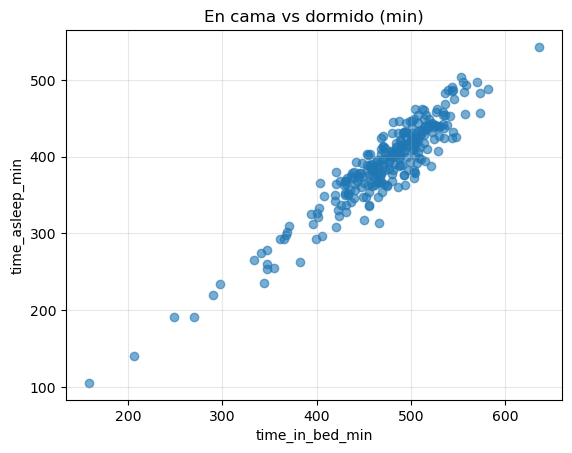

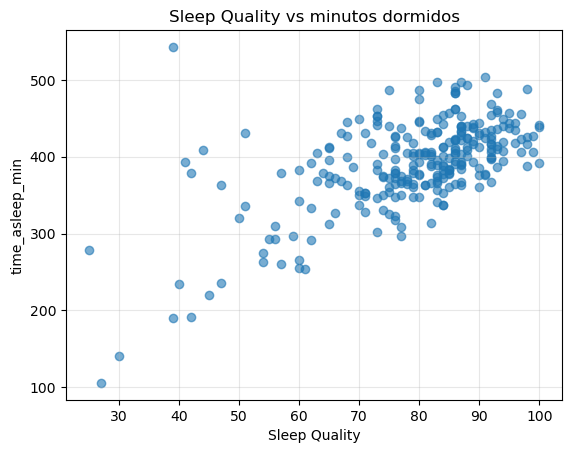

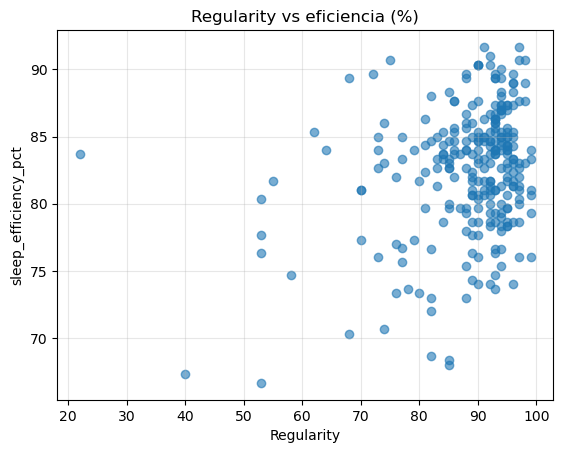

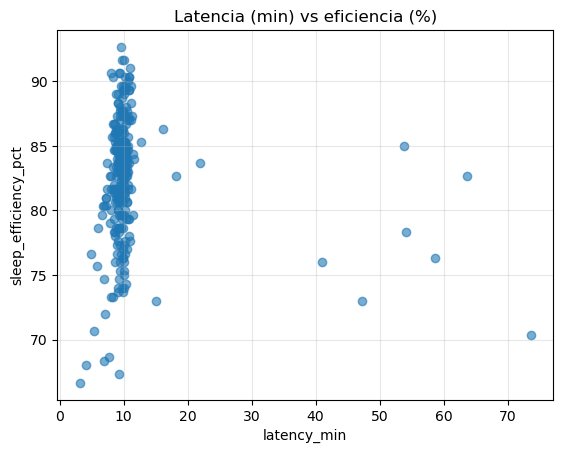

In [8]:
plt.figure()
plt.scatter(df_analysis["time_in_bed_min"], df_analysis["time_asleep_min"], alpha=0.6)
plt.title("En cama vs dormido (min)")
plt.xlabel("time_in_bed_min")
plt.ylabel("time_asleep_min")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.scatter(df_analysis["Sleep Quality"], df_analysis["time_asleep_min"], alpha=0.6)
plt.title("Sleep Quality vs minutos dormidos")
plt.xlabel("Sleep Quality")
plt.ylabel("time_asleep_min")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.scatter(df_analysis["Regularity"], df_analysis["sleep_efficiency_pct"], alpha=0.6)
plt.title("Regularity vs eficiencia (%)")
plt.xlabel("Regularity")
plt.ylabel("sleep_efficiency_pct")
plt.grid(True, alpha=0.3)
plt.show()

if df_analysis["latency_min"].notna().any():
    plt.figure()
    plt.scatter(df_analysis["latency_min"], df_analysis["sleep_efficiency_pct"], alpha=0.6)
    plt.title("Latencia (min) vs eficiencia (%)")
    plt.xlabel("latency_min")
    plt.ylabel("sleep_efficiency_pct")
    plt.grid(True, alpha=0.3)
    plt.show()

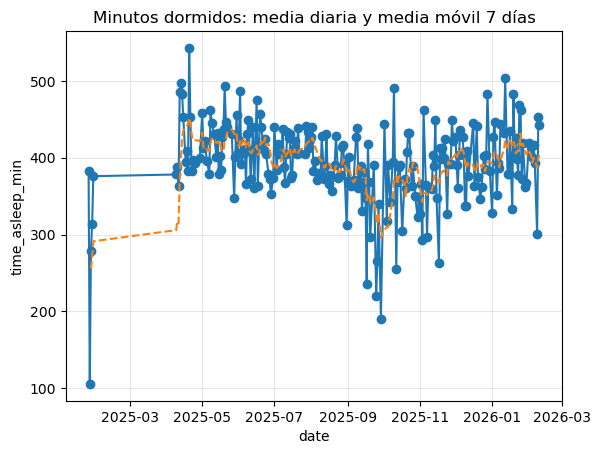

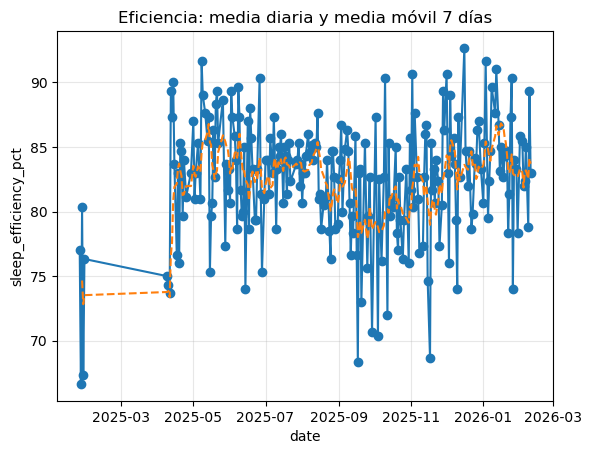

In [9]:
df_ts = df_analysis.dropna(subset=["Went to bed"]).copy()
df_ts["date"] = df_ts["Went to bed"].dt.date
daily = (
    df_ts.groupby("date", observed=True)
    .agg(
        asleep_mean=("time_asleep_min", "mean"),
        eff_mean=("sleep_efficiency_pct", "mean"),
        n=("time_asleep_min", "size")
    )
    .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date")
daily["asleep_7d"] = daily["asleep_mean"].rolling(7, min_periods=3).mean()
daily["eff_7d"] = daily["eff_mean"].rolling(7, min_periods=3).mean()

plt.figure()
plt.plot(daily["date"], daily["asleep_mean"], marker="o", linestyle="-")
plt.plot(daily["date"], daily["asleep_7d"], linestyle="--")
plt.title("Minutos dormidos: media diaria y media móvil 7 días")
plt.xlabel("date")
plt.ylabel("time_asleep_min")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.plot(daily["date"], daily["eff_mean"], marker="o", linestyle="-")
plt.plot(daily["date"], daily["eff_7d"], linestyle="--")
plt.title("Eficiencia: media diaria y media móvil 7 días")
plt.xlabel("date")
plt.ylabel("sleep_efficiency_pct")
plt.grid(True, alpha=0.3)
plt.show()

Spearman Sleep Quality vs time_asleep_min: {'n': 273, 'spearman_r': 0.52611371005956, 'p_value': 7.758605223290738e-21}
Spearman Sleep Quality vs efficiency: {'n': 273, 'spearman_r': 0.12688754427815555, 'p_value': 0.036136937880739656}
Spearman Regularity vs time_asleep_min (sin reg=0): {'n': 265, 'spearman_r': 0.18426840807481812, 'p_value': 0.002601142123594602}
Spearman Regularity vs efficiency (sin reg=0): {'n': 265, 'spearman_r': 0.18544404809425152, 'p_value': 0.002438487006610111}


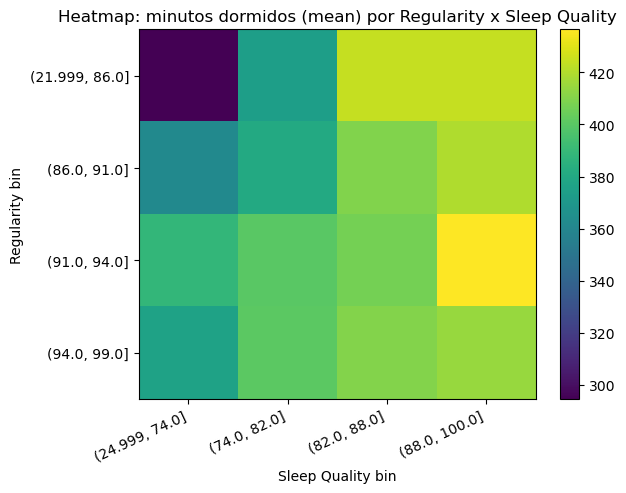

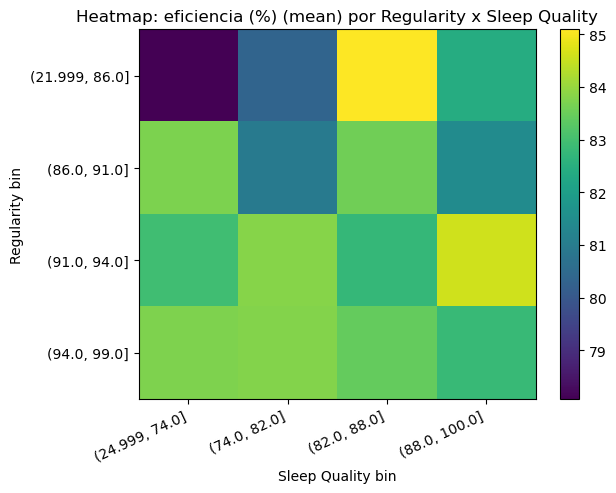

(          reg_bin   n  asleep_mean   eff_mean
 0  (21.999, 86.0]  74   365.717568  80.751492
 1    (86.0, 91.0]  59   391.318644  82.677126
 2    (91.0, 94.0]  70   406.473571  83.384909
 3    (94.0, 99.0]  62   403.370430  83.364979,
            sq_bin   n  asleep_mean   eff_mean
 0  (24.999, 74.0]  70   345.346190  81.442196
 1    (74.0, 82.0]  63   388.378307  82.168598
 2    (82.0, 88.0]  72   411.019907  83.485261
 3   (88.0, 100.0]  60   422.958611  82.843649)

In [10]:
df_b = df_analysis.copy()
df_b.loc[df_b["Regularity"].eq(0), "Regularity"] = pd.NA
df_b = df_b.dropna(subset=["Regularity", "Sleep Quality", "time_asleep_min", "sleep_efficiency_pct"]).copy()

# Bins por cuantiles
df_b["reg_bin"] = pd.qcut(df_b["Regularity"], q=4, duplicates="drop")
df_b["sq_bin"] = pd.qcut(df_b["Sleep Quality"], q=4, duplicates="drop")

summary_reg = df_b.groupby("reg_bin", observed=True).agg(
    n=("Regularity", "size"),
    asleep_mean=("time_asleep_min", "mean"),
    eff_mean=("sleep_efficiency_pct", "mean"),
).reset_index()

summary_sq = df_b.groupby("sq_bin", observed=True).agg(
    n=("Sleep Quality", "size"),
    asleep_mean=("time_asleep_min", "mean"),
    eff_mean=("sleep_efficiency_pct", "mean"),
).reset_index()

tab2d = df_b.groupby(["reg_bin", "sq_bin"], observed=True).agg(
    n=("time_asleep_min", "size"),
    asleep_mean=("time_asleep_min", "mean"),
    eff_mean=("sleep_efficiency_pct", "mean"),
).reset_index()

pivot_asleep = tab2d.pivot(index="reg_bin", columns="sq_bin", values="asleep_mean")
pivot_eff = tab2d.pivot(index="reg_bin", columns="sq_bin", values="eff_mean")

print("Spearman Sleep Quality vs time_asleep_min:", spearman_pair(df_analysis, "Sleep Quality", "time_asleep_min"))
print("Spearman Sleep Quality vs efficiency:", spearman_pair(df_analysis, "Sleep Quality", "sleep_efficiency_pct"))

print("Spearman Regularity vs time_asleep_min (sin reg=0):", spearman_pair(df_b, "Regularity", "time_asleep_min"))
print("Spearman Regularity vs efficiency (sin reg=0):", spearman_pair(df_b, "Regularity", "sleep_efficiency_pct"))

# Heatmap minutos
plt.figure()
plt.imshow(pivot_asleep.values, aspect="auto")
plt.title("Heatmap: minutos dormidos (mean) por Regularity x Sleep Quality")
plt.xlabel("Sleep Quality bin")
plt.ylabel("Regularity bin")
plt.xticks(range(pivot_asleep.shape[1]), [str(c) for c in pivot_asleep.columns], rotation=25, ha="right")
plt.yticks(range(pivot_asleep.shape[0]), [str(i) for i in pivot_asleep.index])
plt.colorbar()
plt.show()

# Heatmap eficiencia
plt.figure()
plt.imshow(pivot_eff.values, aspect="auto")
plt.title("Heatmap: eficiencia (%) (mean) por Regularity x Sleep Quality")
plt.xlabel("Sleep Quality bin")
plt.ylabel("Regularity bin")
plt.xticks(range(pivot_eff.shape[1]), [str(c) for c in pivot_eff.columns], rotation=25, ha="right")
plt.yticks(range(pivot_eff.shape[0]), [str(i) for i in pivot_eff.index])
plt.colorbar()
plt.show()

summary_reg, summary_sq

# =============== MODELADO ================

In [11]:
df_m = df_analysis.dropna(subset=["Went to bed", "time_asleep_min"]).copy()
df_m = df_m.sort_values("Went to bed")

# Calendario y bed_hour (pero se usa lag/rolling para evitar fuga)
df_m["weekday"] = df_m["Went to bed"].dt.day_name()
df_m["month"] = df_m["Went to bed"].dt.month
df_m["bed_hour"] = (
    df_m["Went to bed"].dt.hour
    + df_m["Went to bed"].dt.minute / 60
    + df_m["Went to bed"].dt.second / 3600
)

target = "time_asleep_min"
base_cols = [target, "sleep_efficiency_pct", "latency_min", "bed_hour", "Regularity"]
base_cols = [c for c in base_cols if c in df_m.columns]

# Lags + rolling7 solo con pasado
for col in base_cols:
    df_m[f"{col}_lag1"] = df_m[col].shift(1)
    df_m[f"{col}_roll7"] = df_m[col].shift(1).rolling(7, min_periods=3).mean()

feature_cols = ["weekday", "month"] + [f"{c}_lag1" for c in base_cols] + [f"{c}_roll7" for c in base_cols]
feature_cols = [c for c in feature_cols if c in df_m.columns]

df_model = df_m.dropna(subset=[target, f"{target}_lag1"]).copy()

# Split temporal 80/20
cut = int(len(df_model) * 0.8)
train = df_model.iloc[:cut].copy()
test  = df_model.iloc[cut:].copy()

X_train, y_train = train[feature_cols], train[target]
X_test, y_test   = test[feature_cols], test[target]

# Baselines
mae_last = mean_absolute_error(y_test, test[f"{target}_lag1"])
mae_roll7 = mean_absolute_error(y_test, test[f"{target}_roll7"])

# Pipeline Ridge
cat_cols = [c for c in ["weekday"] if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

alpha_ridge = 100.0
model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", Ridge(alpha=alpha_ridge, random_state=0))
])

model.fit(X_train, y_train)
pred_test = model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_test)

print("MAE baseline last:", mae_last)
print("MAE baseline roll7:", mae_roll7)
print("MAE Ridge:", mae_ridge)

# Intervalos rolling conformal 90% usando errores del final del train
pred_train = model.predict(X_train)
abs_err_train = np.abs(y_train.values - pred_train)

W = 60
alpha = 0.10  # 90%
history_errs = abs_err_train[-min(W, len(abs_err_train)):]

def conformal_q(errs, alpha):
    n = len(errs)
    level = np.ceil((n + 1) * (1 - alpha)) / n
    level = min(level, 1.0)
    return float(np.quantile(errs, level))

q = conformal_q(history_errs, alpha)
low = pred_test - q
high = pred_test + q

coverage = float(np.mean((y_test.values >= low) & (y_test.values <= high)))
avg_width = float(np.mean(high - low))

print("Cobertura empírica (objetivo 90%):", coverage)
print("Ancho medio intervalo (min):", avg_width, "half-width q:", q)

test_pred = test.copy()
test_pred["pred"] = pred_test
test_pred["low_90"] = low
test_pred["high_90"] = high
test_pred["abs_err"] = np.abs(test_pred[target].values - test_pred["pred"].values)

test_pred[["Went to bed", target, "pred", "low_90", "high_90", "abs_err"]].head(10)

MAE baseline last: 62.19545454545454
MAE baseline roll7: 47.939047619047614
MAE Ridge: 45.62465555173434
Cobertura empírica (objetivo 90%): 0.9272727272727272
Ancho medio intervalo (min): 203.3019598172066 half-width q: 101.6509799086033


,Went to bed,time_asleep_min,pred,low_90,high_90,abs_err
221,2025-12-10 23:45:18,337.233333,387.987060,286.336080,489.638040,50.753727
222,2025-12-11 23:34:48,409.266667,388.187439,286.536459,489.838419,21.079228
223,2025-12-12 23:43:43,376.333333,392.187075,290.536095,493.838055,15.853742
224,2025-12-16 22:50:34,445.583333,385.457935,283.806955,487.108914,60.125399
225,2025-12-17 23:41:08,363.416667,383.804232,282.153252,485.455212,20.387565
226,2025-12-19 22:45:49,441.066667,369.690873,268.039893,471.341853,71.375793
227,2025-12-20 23:59:22,375.383333,366.878810,265.227830,468.529789,8.504524
228,2025-12-22 00:03:14,345.666667,374.737373,273.086393,476.388353,29.070706
229,2025-12-23 01:11:26,301.383333,399.766169,298.115190,501.417149,98.382836
230,2025-12-23 22:50:46,423.650000,393.307314,291.656334,494.958294,30.342686


In [12]:
from sklearn.preprocessing import StandardScaler

prep_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

ridge_interp = Pipeline(steps=[
    ("prep", prep_scaled),
    ("model", Ridge(alpha=alpha_ridge, random_state=0))
])
ridge_interp.fit(X_train, y_train)

ohe = ridge_interp.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(cat_cols).tolist() if len(cat_cols) else []
feat_names = num_cols + cat_names

coefs = ridge_interp.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df.sort_values("abs_coef", ascending=False).head(20)

,feature,coef,abs_coef
6,time_asleep_min_roll7,9.842585,9.842585
8,latency_min_roll7,-8.106345,8.106345
4,bed_hour_lag1,-4.866496,4.866496
10,Regularity_roll7,-4.739111,4.739111
3,latency_min_lag1,3.468691,3.468691
0,month,-2.925343,2.925343
13,weekday_Saturday,-2.333935,2.333935
9,bed_hour_roll7,2.221413,2.221413
7,sleep_efficiency_pct_roll7,1.958503,1.958503
15,weekday_Thursday,1.817129,1.817129


In [13]:
def predict_next_night(
    df_history: pd.DataFrame,
    model_pipeline,
    feature_cols: list[str],
    target_col="time_asleep_min",
    W=60,
    alpha=0.10,
    next_date=None
):
    df_h = df_history.sort_values("Went to bed").copy()

    last_dt = df_h["Went to bed"].iloc[-1]
    if next_date is None:
        next_date = (pd.Timestamp(last_dt).normalize() + pd.Timedelta(days=1))

    next_weekday = pd.Timestamp(next_date).day_name()
    next_month = int(pd.Timestamp(next_date).month)

    last_row = df_h.iloc[-1]
    x_next = {}
    for c in feature_cols:
        if c == "weekday":
            x_next[c] = next_weekday
        elif c == "month":
            x_next[c] = next_month
        else:
            x_next[c] = last_row.get(c, np.nan)

    X_next = pd.DataFrame([x_next])
    pred = float(model_pipeline.predict(X_next)[0])

    # errores para conformal (últimas W observaciones del historial con features disponibles)
    need_cols = ["Went to bed", target_col] + feature_cols
    df_for_err = df_h.dropna(subset=[c for c in need_cols if c in df_h.columns]).copy()
    X_hist = df_for_err[feature_cols]
    y_hist = df_for_err[target_col].values
    pred_hist = model_pipeline.predict(X_hist)
    abs_err = np.abs(y_hist - pred_hist)
    abs_err_window = abs_err[-min(W, len(abs_err)):]
    q = conformal_q(abs_err_window, alpha)

    return {
        "next_date": pd.Timestamp(next_date),
        "next_weekday": next_weekday,
        "next_month": next_month,
        "pred": pred,
        "low": pred - q,
        "high": pred + q,
        "interval_level": 1 - alpha,
        "half_width_q": q
    }

def pretty_sleep_forecast(result: dict, short_threshold_min: int = 360) -> dict:
    pred = result["pred"]
    low = result["low"]
    high = result["high"]

    out = {
        "date": str(result["next_date"].date()),
        "weekday": result["next_weekday"],
        "pred_min": pred,
        "low_min": low,
        "high_min": high,
        "pred_hm": fmt_min_to_hm(pred),
        "low_hm": fmt_min_to_hm(low),
        "high_hm": fmt_min_to_hm(high),
        "interval_level": result["interval_level"],
        "half_width_min": result["half_width_q"],
        "half_width_hm": fmt_min_to_hm(result["half_width_q"]),
        "flag_risk_short_sleep": bool(pred < short_threshold_min),
        "short_threshold_hm": fmt_min_to_hm(short_threshold_min),
    }
    return out

# Ejemplo real: predecir la próxima noche usando df_model
result = predict_next_night(
    df_history=df_model,
    model_pipeline=model,
    feature_cols=feature_cols,
    target_col=target,
    W=60,
    alpha=0.10
)
report = pretty_sleep_forecast(result, short_threshold_min=360)

print(f"Predicción próxima noche ({report['date']} - {report['weekday']}):")
print(f"- Sueño esperado: {report['pred_hm']} ({report['pred_min']:.1f} min)")
print(f"- Intervalo {int(report['interval_level']*100)}%: [{report['low_hm']} , {report['high_hm']}]")
print(f"- Incertidumbre aprox: ±{report['half_width_hm']} (±{report['half_width_min']:.1f} min)")
print(f"- Umbral noche corta (< {report['short_threshold_hm']}): {report['flag_risk_short_sleep']}")

report

Predicción próxima noche (2026-02-11 - Wednesday):
- Sueño esperado: 6h 36m (395.8 min)
- Intervalo 90%: [4h 57m , 8h 14m]
- Incertidumbre aprox: ±1h 38m (±98.4 min)
- Umbral noche corta (< 6h 00m): False


{'date': '2026-02-11',
 'weekday': 'Wednesday',
 'pred_min': 395.84745597546566,
 'low_min': 297.44704299098856,
 'high_min': 494.24786895994276,
 'pred_hm': '6h 36m',
 'low_hm': '4h 57m',
 'high_hm': '8h 14m',
 'interval_level': 0.9,
 'half_width_min': 98.4004129844771,
 'half_width_hm': '1h 38m',
 'flag_risk_short_sleep': False,
 'short_threshold_hm': '6h 00m'}

In [14]:
import joblib

bundle = {
    "model": model,
    "feature_cols": feature_cols,
    "target": target,
    "alpha_ridge": alpha_ridge,
    "conformal_window_W": W,
    "interval_alpha": alpha
}

joblib.dump(bundle, "sleep_ridge_bundle.joblib")
print("Guardado: sleep_ridge_bundle.joblib")

Guardado: sleep_ridge_bundle.joblib
